# Figure 5A, C and D — interactions between knockouts from different modules

Fits every response gene against the six guide modules and their pairwise
interactions, keeps the coefficients that survive FDR correction, and lays them
out gene by gene. The last section takes each pair of modules on its own and
asks whether the interaction agrees in sign with the two main effects.

## Setup

In [1]:
library(pheatmap)
library(ggplot2)
library(data.table)   # before reshape2: both define melt()
library(reshape2)

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x and silently breaks every "+"
# chain, producing a blank PDF. %ni% and save_pheatmap_pdf are inlined from
# Utilities.R.

`%ni%` <- Negate(`%in%`)

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

RDS_DIR   <- "/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles"
MODULE_CSV <- "/home/eraslab1/Projects/E3Ligase/analysisSingle/TextFiles/ME_GeneModules_leiden_11_Modules.csv"

HEATMAP_PDF     <- "figures/Figure_5D.pdf"
HEATMAP_CSV     <- "outputs/Fig_5D.csv"
INTERACTION_PDF <- "figures/Figure_S6B.pdf"

FDR_CUTOFF  <- 0.1
EFFECT_CLIP <- 0.2

# Terms are keyed by the old module names, in three shapes: "K_0" for a main
# effect, "K_0:K_1" for an interaction, "K0:K0" for two knockouts from one
# module. Tables are indexed with those and relabelled only where displayed.
MODULE_OF_K <- c("0" = "M2", "1" = "M3", "2" = "M6", "3" = "M5", "4" = "M1", "5" = "M4")

moduleLabel <- function(x) {
    for (k in names(MODULE_OF_K)) x <- gsub(paste0("K_?", k), MODULE_OF_K[[k]], x)
    x
}

annoCols <- list(GeneGroup = c(G0 = "#A6CEE3", G1 = "#1F78B4", G2  = "#B2DF8A", G3 = "#33A02C",
                               G4 = "#FB9A99", G5 = "#FDBF6F", G6  = "#FF7F00", G7 = "#CAB2D6",
                               G8 = "#6A3D9A", G9 = "#FFFF99", G10 = "#B5651D"))


Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt




## Gene modules

The module table spells some genes the way R's `make.names` left them, where
the effect tables use the original symbols. The two are reconciled here so the
gene sets line up.

In [2]:
# Module table spelling -> effect table spelling.
GENE_NAME_FIXES <- c(
    X2010111I01Rik = "2010111I01Rik", X0610012G03Rik = "0610012G03Rik",
    X2010005H15Rik = "2010005H15Rik", X2310001H17Rik = "2310001H17Rik",
    X2810474O19Rik = "2810474O19Rik",
    H2.M2  = "H2-M2",  H2.Q6   = "H2-Q6",   H2.Q7  = "H2-Q7",  H2.D1  = "H2-D1",
    H2.K1  = "H2-K1",  H2.T23  = "H2-T23",  H2.Aa  = "H2-Aa",  H2.Ab1 = "H2-Ab1",
    H2.DMa = "H2-DMa", H2.DMb1 = "H2-DMb1", H2.Eb1 = "H2-Eb1")

fixGeneNames <- function(x) ifelse(x %in% names(GENE_NAME_FIXES), GENE_NAME_FIXES[x], x)

myGeneModules <- read.csv(MODULE_CSV, row.names = 1, stringsAsFactors = FALSE)
rownames(myGeneModules) <- fixGeneNames(myGeneModules$GeneName)

# One module column, so the heatmaps get a single annotation track.
myGeneModules[c("GeneName", "NewGeneGroup", "GeneColor")] <- NULL
myGeneModules$GeneGroup <- factor(myGeneModules$GeneGroup)

table(myGeneModules$GeneGroup)


 G0  G1 G10  G2  G3  G4  G5  G6  G7  G8  G9 
120 116  26 141  94 141  78 143  86  65  31 

## Effect sizes

`combosInter` holds the module main effects and their interactions, with
coefficients failing FDR correction set to zero. `doubleRes` holds the effect
of carrying two knockouts from the same module, and is appended as five further
terms. `cMean1` is the mean expression in control cells, centred, which becomes
the bottom row of the heatmap.

In [3]:
toWide <- function(d, valueColumn) {
    keep <- c("respGene", "term", valueColumn)
    d <- reshape(d[, keep], idvar = "respGene", timevar = "term", direction = "wide")
    rownames(d) <- d$respGene
    d$respGene  <- NULL
    colnames(d) <- sub(paste0("^", valueColumn, "\\."), "", colnames(d))
    d
}

combosInter <- readRDS(file.path(RDS_DIR, "ComboEffects_lm_residuals_withInteractions.rds"))
combosInter <- combosInter[combosInter$term %ni%
                           c("(Intercept)", "n_genes", "mt_frac", paste0("leiden", 1:9)), ]

combosInter <- data.table(combosInter)
combosInter[, FDR := p.adjust(p.value, method = "fdr", n = length(p.value)), by = respGene]
combosInter <- data.frame(combosInter)

combosInterFDR <- toWide(combosInter, "FDR")
combosInter    <- toWide(combosInter, "estimate")
stopifnot(identical(dimnames(combosInter), dimnames(combosInterFDR)))

combosInter[combosInterFDR > FDR_CUTOFF] <- 0
write.csv(combosInter, "outputs/CombosInter.csv")

doubleRes <- readRDS(file.path(RDS_DIR, "ComboEffects_doublesResampleRes.rds"))
rownames(doubleRes) <- doubleRes$respGene
doubleRes$respGene  <- NULL

cMean1 <- readRDS(file.path(RDS_DIR, "ControlCellsMeanExp.rds"))
rownames(cMean1) <- cMean1$Genes
cMean1 <- data.frame(scale(cMean1[, "MeanExp_Cont2", drop = FALSE], center = TRUE, scale = FALSE))

combosInter <- cbind(combosInter, doubleRes[rownames(combosInter), ])

# The three kinds of term, named once and used by every panel below.
mainTerms        <- paste0("K_", 0:5)
intraModuleTerms <- colnames(doubleRes)                                        # two knockouts from one module
interModuleTerms <- setdiff(colnames(combosInter), c(mainTerms, intraModuleTerms))

dim(combosInter)

[1] 1041   26

## Ordering the genes and the terms

Genes are ordered within their own module, by clustering each module's block on
its own, and the terms are then clustered across the whole matrix. Both of
those heatmaps exist only for the orderings they produce, so they are drawn
silently.

In [4]:
combosInterPlot <- as.matrix(combosInter[rownames(myGeneModules), ])
combosInterPlot[combosInterPlot >  EFFECT_CLIP] <-  EFFECT_CLIP
combosInterPlot[combosInterPlot < -EFFECT_CLIP] <- -EFFECT_CLIP
combosInterPlot <- t(combosInterPlot)
colnames(combosInterPlot) <- rownames(myGeneModules)
rownames(combosInterPlot) <- moduleLabel(rownames(combosInterPlot))

myGeneOrder <- unlist(lapply(unique(myGeneModules$GeneGroup), function(elem) {
    block <- combosInterPlot[, rownames(myGeneModules)[myGeneModules$GeneGroup == elem]]
    k <- pheatmap(block, cluster_rows = FALSE, clustering_method = "ward.D2",
                  colorRampPalette(c("blue", "white", "orange"))(100), silent = TRUE)
    colnames(block)[k$tree_col$order]
}))

km2 <- pheatmap(combosInterPlot[, myGeneOrder], cluster_cols = FALSE, cluster_rows = TRUE,
                clustering_method = "ward.D", silent = TRUE)
myrowOrder <- rownames(combosInterPlot)[km2$tree_row$order]

## Figure 5D

The control row is appended as a matrix row rather than through `data.frame()`,
which would put R's `make.names` back over the gene symbols and need undoing a
second time.

agg_record_1113940670 
                    2

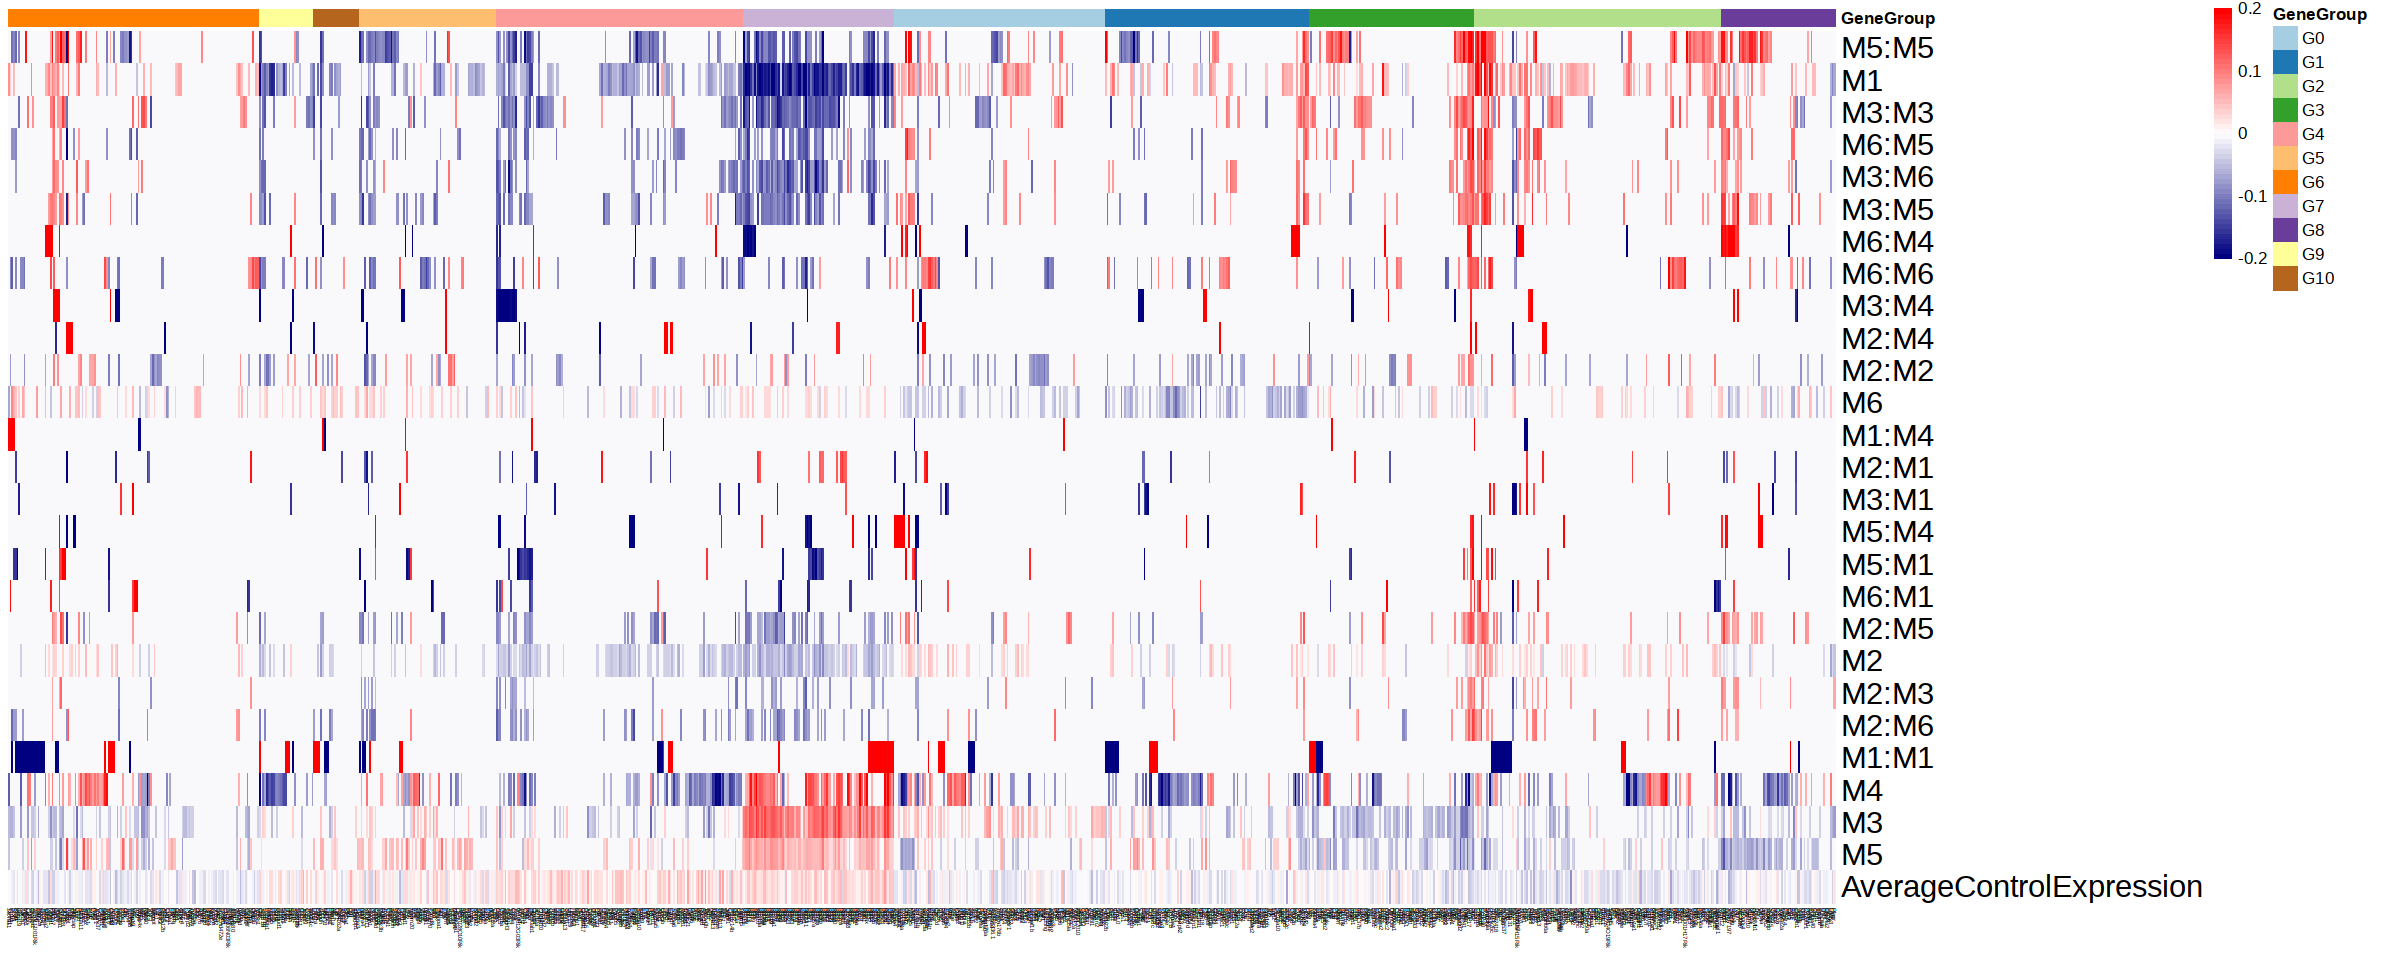

In [5]:
combosInterPlot <- rbind(combosInterPlot,
                         AverageControlExpression = cMean1[myGeneOrder, "MeanExp_Cont2"])

plotOrder <- c(myrowOrder, "AverageControlExpression")
myAnno    <- myGeneModules[myGeneOrder, , drop = FALSE]

options(repr.plot.width = 20, repr.plot.height = 8)
xx <- pheatmap(combosInterPlot[plotOrder, myGeneOrder],
               cluster_cols = FALSE,
               cluster_rows = FALSE,
               clustering_method = "ward.D",
               treeheight_col = 0, fontsize_col = 3, fontsize_row = 18,
               annotation_col = myAnno,
               annotation_colors = annoCols,
               colorRampPalette(c("navy", "white", "red"))(50))

save_pheatmap_pdf(xx, HEATMAP_PDF, width = 20, height = 8)
write.csv(combosInterPlot[plotOrder, myGeneOrder], HEATMAP_CSV)

## How many genes each term moves

:::{note}
The bar chart below is not written to file; the original's `pdf()` call is
commented out and that is left as it was.
:::

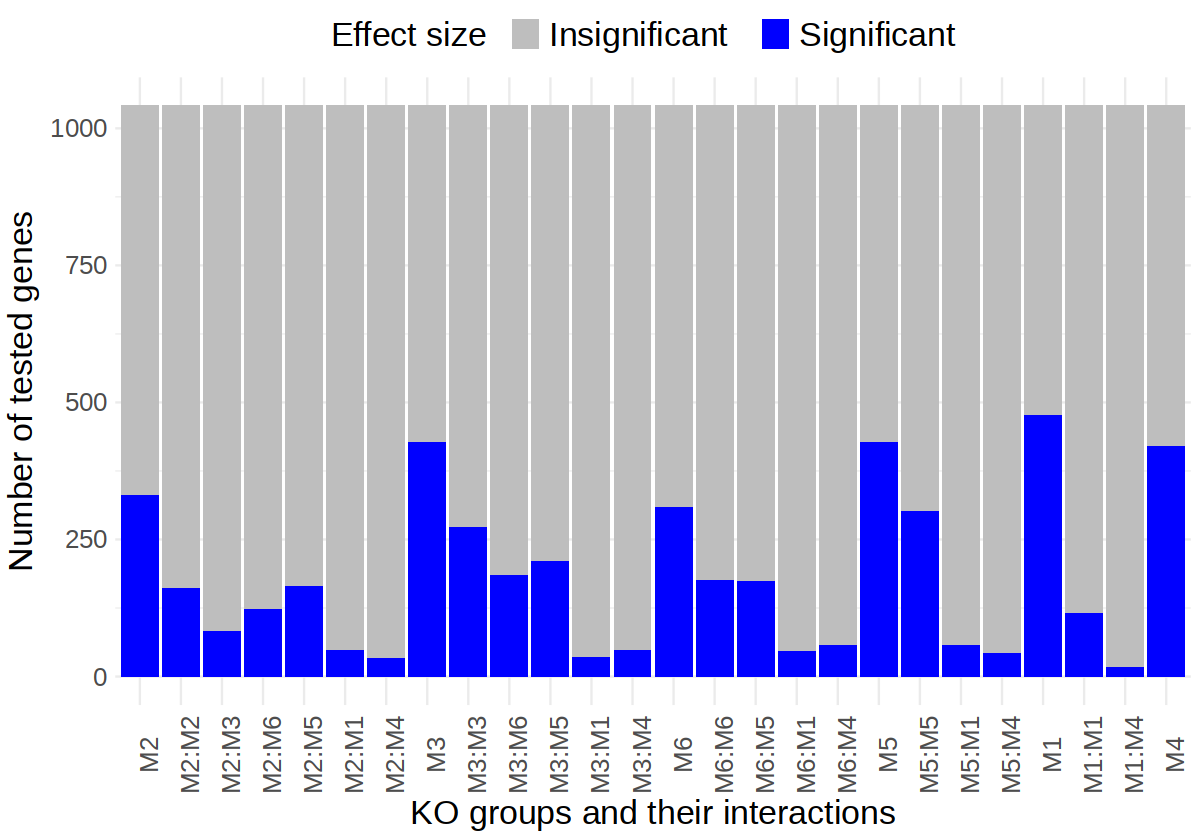

In [6]:
insignificant <- sapply(combosInter, function(x) length(which(x == 0)))

kk <- data.frame(GroupNames  = names(insignificant),
                 Insignificant = insignificant,
                 Significant   = nrow(combosInter) - insignificant)
kk <- melt(kk, id.vars = "GroupNames")

# The original relabelled after setting levels, which dropped them and left
# ggplot to sort the displayed strings; that order is reproduced here.
publishedOrder <- order(gsub("_", "", colnames(combosInter)))
kk$GroupNames  <- factor(moduleLabel(as.character(kk$GroupNames)),
                         levels = moduleLabel(colnames(combosInter))[publishedOrder])

options(repr.plot.width = 10, repr.plot.height = 7)
ggplot(kk, aes(fill = variable, y = value, x = GroupNames)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_fill_manual("Effect size", values = c("grey", "blue")) +
    ylab("Number of tested genes") + theme_minimal() +
    theme(axis.text.y = element_text(size = 15),
          axis.text.x = element_text(size = 15, angle = 90),
          axis.title  = element_text(size = 20),
          strip.text  = element_text(size = 25),
          legend.text = element_text(size = 20),
          legend.title = element_text(size = 20),
          legend.position = "top") +
    xlab("KO groups and their interactions")

### Interactions only, with the same-module ones first

The same counts as above, restricted to the twenty interaction terms -- the
six main effects are not interactions -- and reordered so the five same-module
interactions lead. `coord_cartesian()` crops the axis; `ylim()` would drop the
out-of-range rows and unstack the bars.


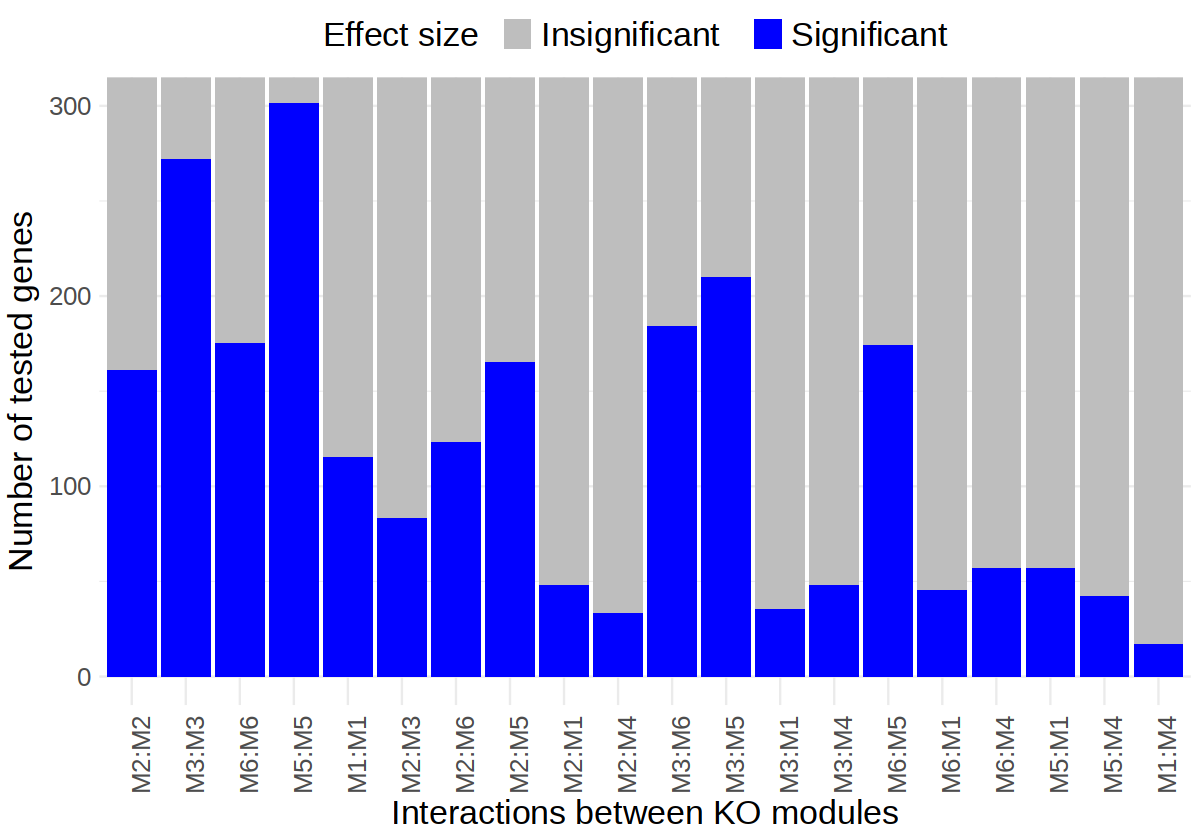

In [7]:
Y_LIMIT <- 300

# Same-module interactions first. They are left in the order the columns come
# in -- K0:K0 to K4:K4, so M2, M3, M6, M5, M1 -- which is the module order used
# throughout; sorting them alphabetically would put M1 first.
intraFirst <- c(moduleLabel(intraModuleTerms),
                setdiff(moduleLabel(colnames(combosInter))[publishedOrder],
                        moduleLabel(intraModuleTerms)))

# Main effects are not interactions, so they are dropped here.
intraFirst <- intraFirst[intraFirst %in% moduleLabel(c(intraModuleTerms, interModuleTerms))]

kkIntraFirst <- kk[as.character(kk$GroupNames) %in% intraFirst, ]
kkIntraFirst$GroupNames <- factor(as.character(kkIntraFirst$GroupNames), levels = intraFirst)

options(repr.plot.width = 10, repr.plot.height = 7)
ggplot(kkIntraFirst, aes(fill = variable, y = value, x = GroupNames)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_fill_manual("Effect size", values = c("grey", "blue")) +
    coord_cartesian(ylim = c(0, Y_LIMIT)) +
    ylab("Number of tested genes") + theme_minimal() +
    theme(axis.text.y = element_text(size = 15),
          axis.text.x = element_text(size = 15, angle = 90),
          axis.title  = element_text(size = 20),
          strip.text  = element_text(size = 25),
          legend.text = element_text(size = 20),
          legend.title = element_text(size = 20),
          legend.position = "top") +
    xlab("Interactions between KO modules")


### The main effects on their own

The six terms taken out of the panel above. These are single-module effects,
not interactions, and they are larger throughout -- 308 to 477 genes against
17 to 301 -- so they are drawn uncropped and on their own axis rather than
compressing the interaction bars.


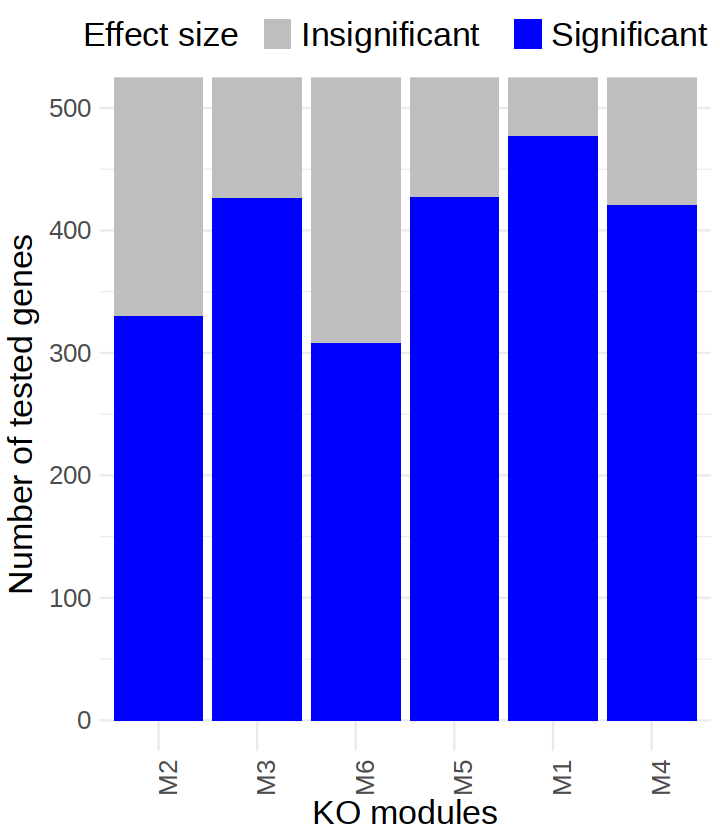

In [8]:
mainOnly <- moduleLabel(mainTerms)   # M2, M3, M6, M5, M1, M4, in module order

kkMain <- kk[as.character(kk$GroupNames) %in% mainOnly, ]
kkMain$GroupNames <- factor(as.character(kkMain$GroupNames), levels = mainOnly)

options(repr.plot.width = 6, repr.plot.height = 7)
ggplot(kkMain, aes(fill = variable, y = value, x = GroupNames)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_fill_manual("Effect size", values = c("grey", "blue")) +
    coord_cartesian(ylim = c(0, 500)) +
    ylab("Number of tested genes") + theme_minimal() +
    theme(axis.text.y = element_text(size = 15),
          axis.text.x = element_text(size = 15, angle = 90),
          axis.title  = element_text(size = 20),
          strip.text  = element_text(size = 25),
          legend.text = element_text(size = 20),
          legend.title = element_text(size = 20),
          legend.position = "top") +
    xlab("KO modules")


## How many interactions each gene has

agg_record_297063065 
                   2

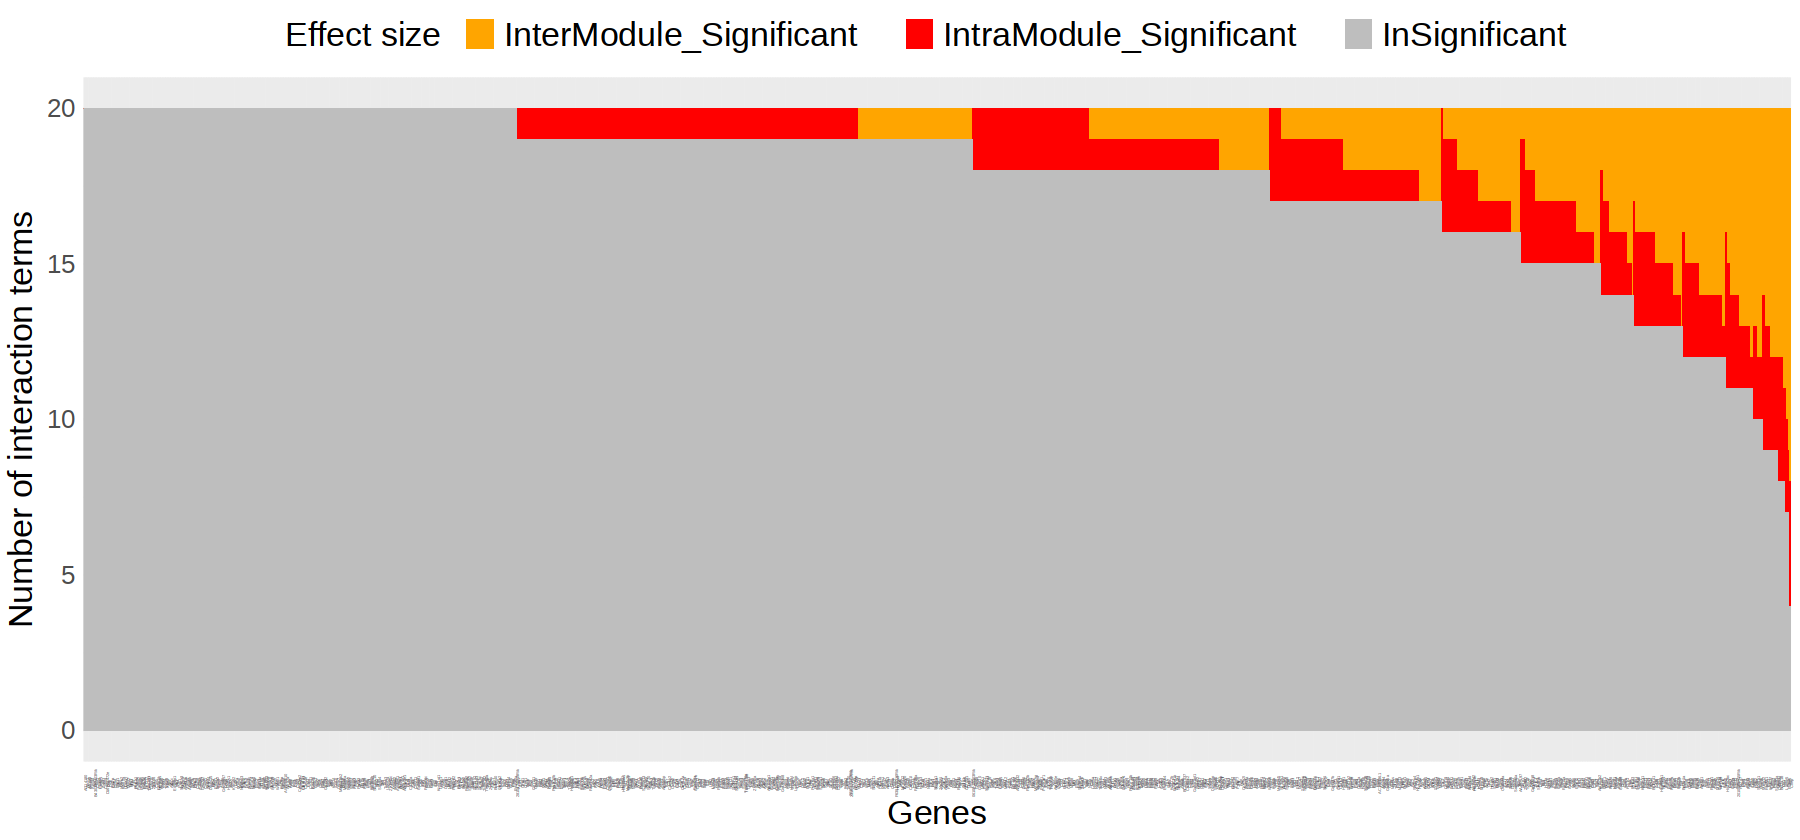

In [9]:
interactionTerms <- c(intraModuleTerms, interModuleTerms)

countNonZero <- function(m) apply(m, 1, function(x) length(which(x != 0)))

kk <- data.frame(GroupNames              = rownames(combosInter),
                 InterModule_Significant = countNonZero(combosInter[, interModuleTerms]),
                 IntraModule_Significant = countNonZero(combosInter[, intraModuleTerms]))
kk$InSignificant <- length(interactionTerms) -
                    (kk$InterModule_Significant + kk$IntraModule_Significant)

kk        <- kk[order(-kk$InSignificant, -kk$IntraModule_Significant, -kk$InterModule_Significant), ]
geneOrder <- kk$GroupNames

kk <- melt(kk, id.vars = "GroupNames")
kk$GroupNames <- factor(kk$GroupNames, levels = geneOrder)

options(repr.plot.width = 15, repr.plot.height = 7)
p <- ggplot(kk, aes(fill = variable, y = value, x = GroupNames)) +
    geom_bar(position = "stack", stat = "identity") +
    scale_fill_manual("Effect size", values = c("orange", "red", "grey")) +
    ylab("Number of interaction terms") + theme_minimal() +
    theme(axis.text.y = element_text(size = 15),
          axis.text.x = element_text(size = 2, angle = 90),
          axis.title  = element_text(size = 20),
          strip.text  = element_text(size = 25),
          legend.text = element_text(size = 20),
          legend.title = element_text(size = 20),
          legend.position = "top") +
    xlab("Genes")

pdf(INTERACTION_PDF, width = 20, height = 8)
print(p)
dev.off()

p

## One panel per pair of modules

For every interaction term that is non-zero somewhere, each gene is shown as
the two module main effects, their sum, the interaction, and the effect of
carrying both knockouts — reduced to sign, so that agreement and disagreement
are what is visible.

In [10]:
mainEffects <- combosInter[, paste0("K_", 0:5)]
mainEffects$Gene <- rownames(mainEffects)
mainLong <- melt(mainEffects, id.vars = "Gene")
mainLong$GeneGroup <- paste0(mainLong$Gene, "_", mainLong$variable)
mainLong <- mainLong[, c("GeneGroup", "value")]

interactions <- combosInter[, interactionTerms]
interactions$Gene <- rownames(interactions)
combosInterMelt <- melt(interactions, id.vars = "Gene")
combosInterMelt <- combosInterMelt[combosInterMelt$value != 0, ]

combosInterMelt$Group1 <- sapply(strsplit(as.character(combosInterMelt$variable), ":"), `[`, 1)
combosInterMelt$Group2 <- sapply(strsplit(as.character(combosInterMelt$variable), ":"), `[`, 2)
combosInterMelt$GeneGroup1 <- paste0(combosInterMelt$Gene, "_", combosInterMelt$Group1)
combosInterMelt$GeneGroup2 <- paste0(combosInterMelt$Gene, "_", combosInterMelt$Group2)

combosInterMelt <- merge(combosInterMelt,
                         setNames(mainLong, c("GeneGroup1", "Group1Value")), by = "GeneGroup1")
combosInterMelt <- merge(combosInterMelt,
                         setNames(mainLong, c("GeneGroup2", "Group2Value")), by = "GeneGroup2")
combosInterMelt <- combosInterMelt[order(combosInterMelt$Group1, combosInterMelt$Group2,
                                         combosInterMelt$Group1Value, combosInterMelt$Group2Value,
                                         combosInterMelt$value), ]
nrow(combosInterMelt)

[1] 1321

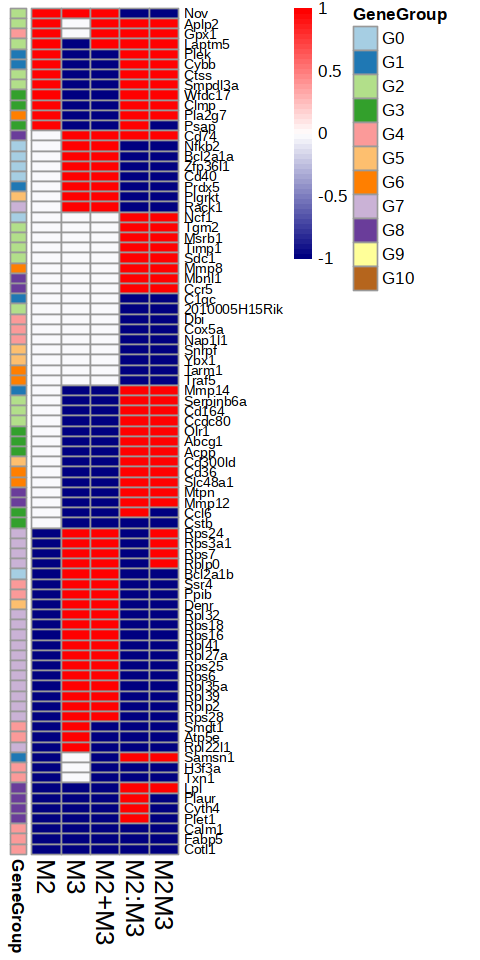

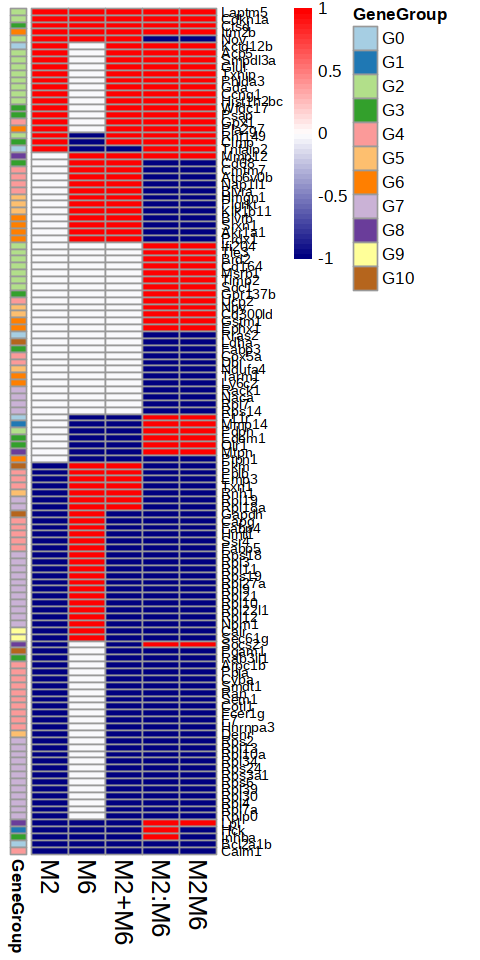

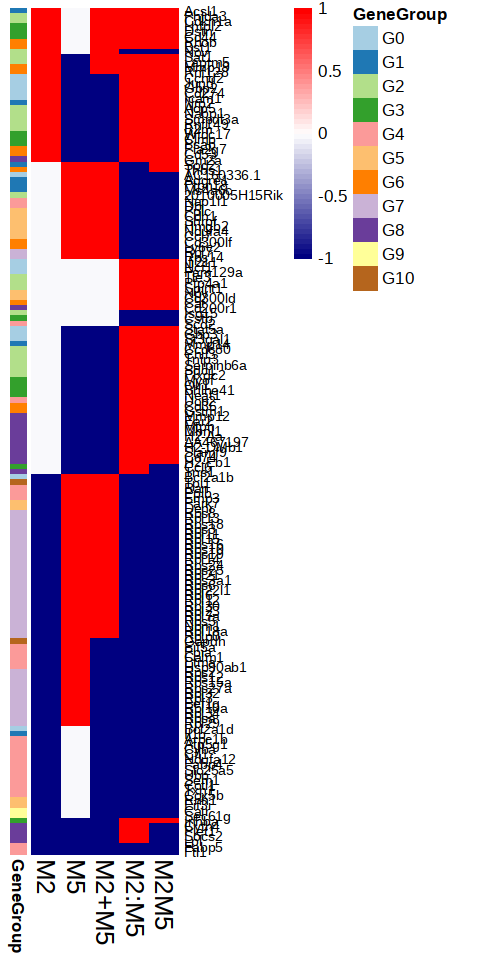

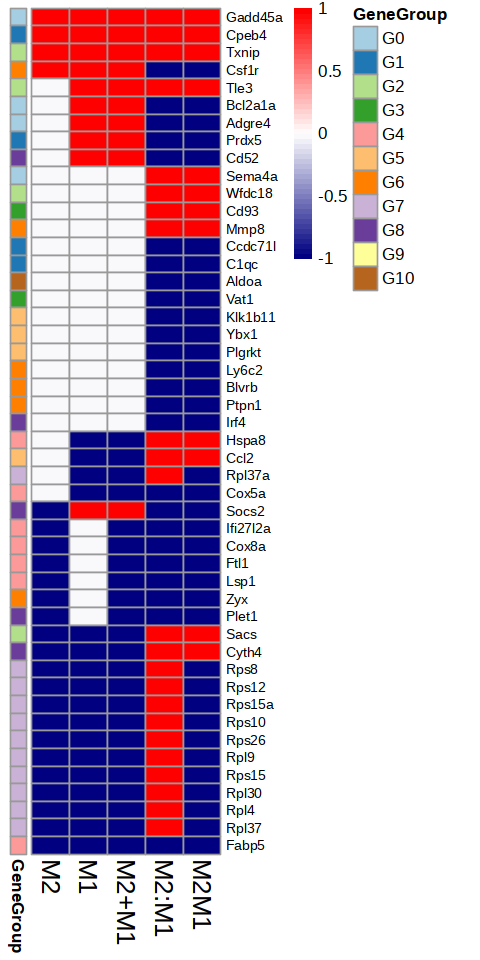

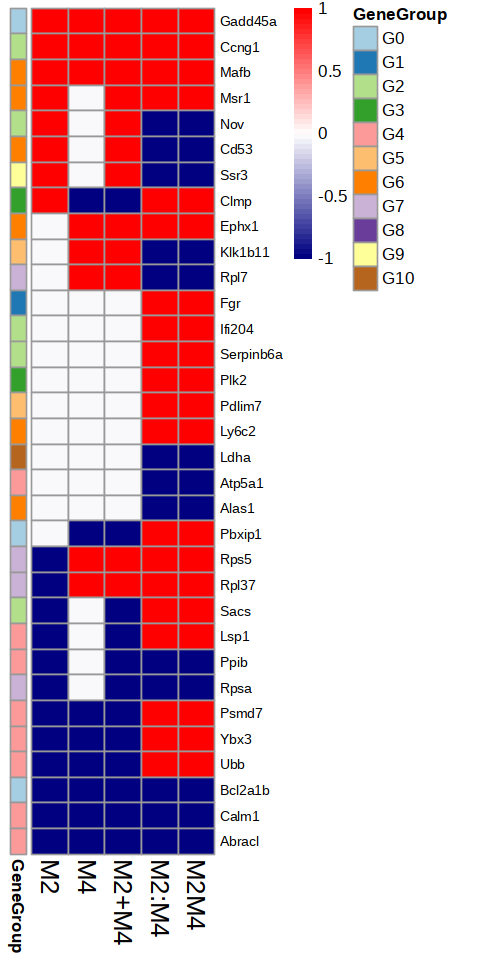

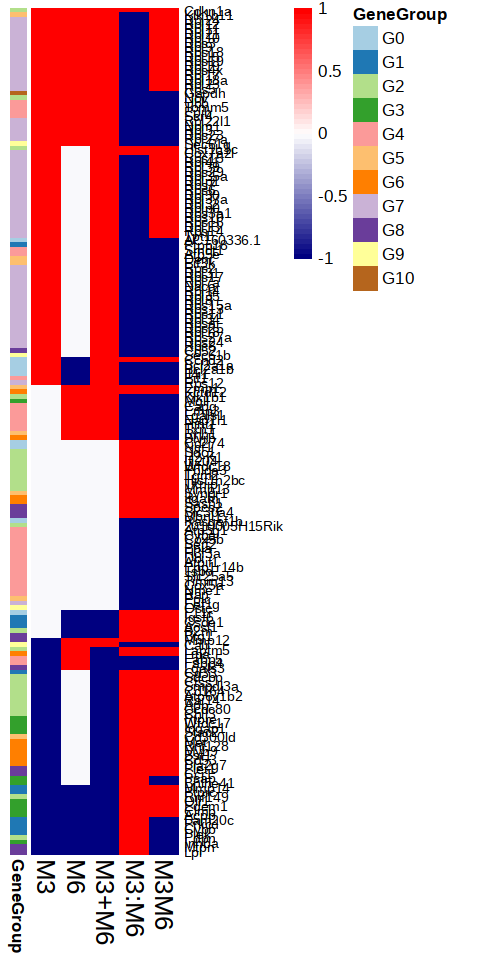

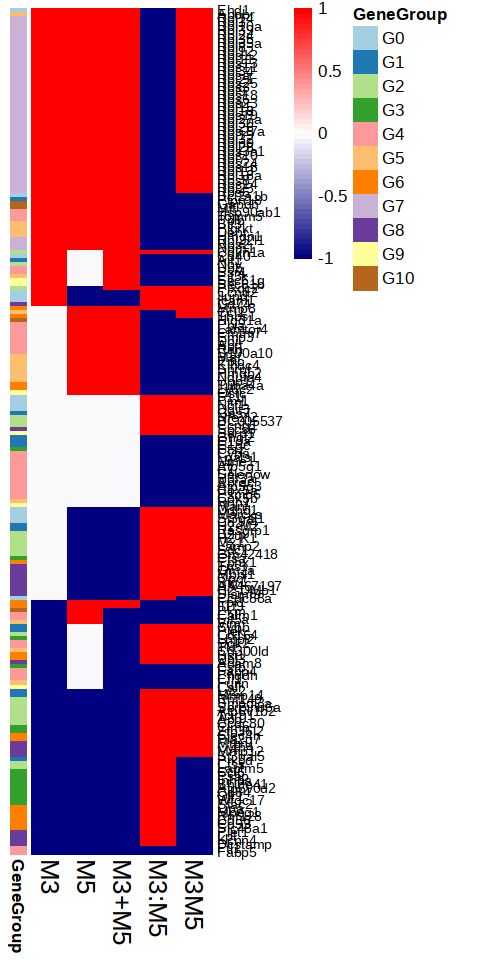

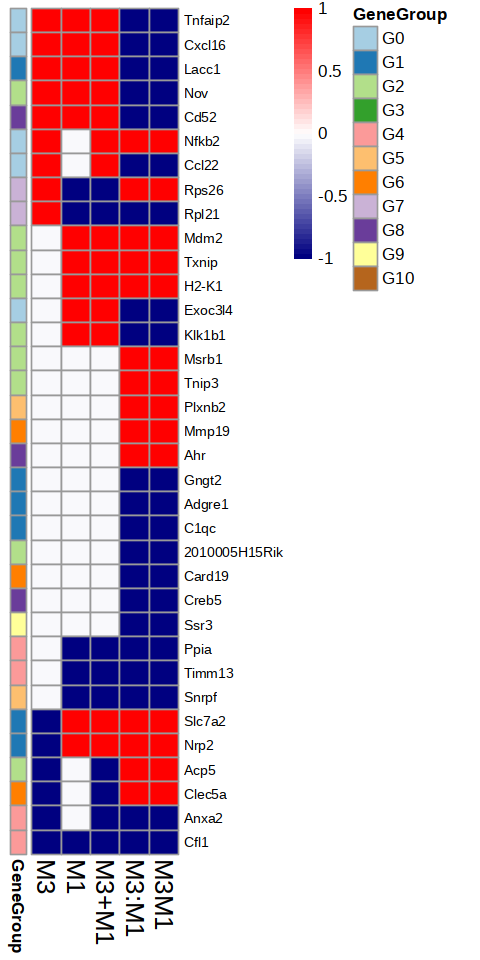

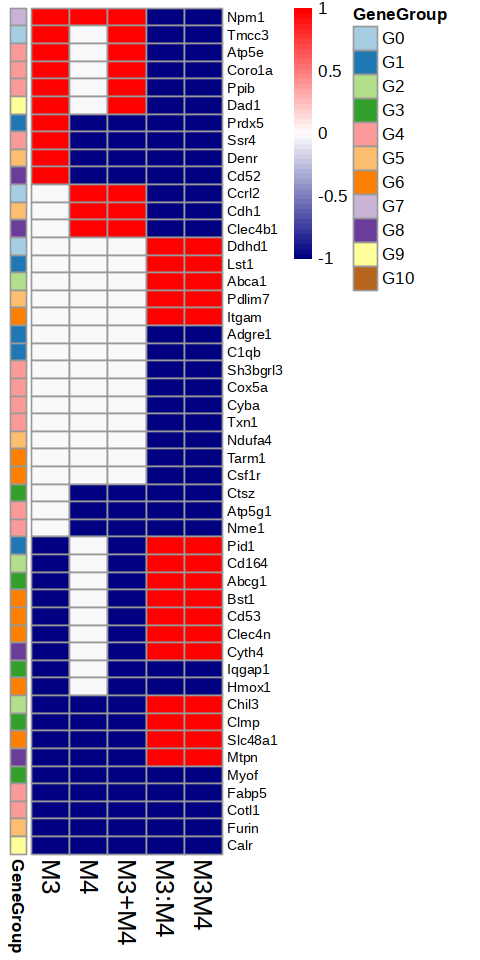

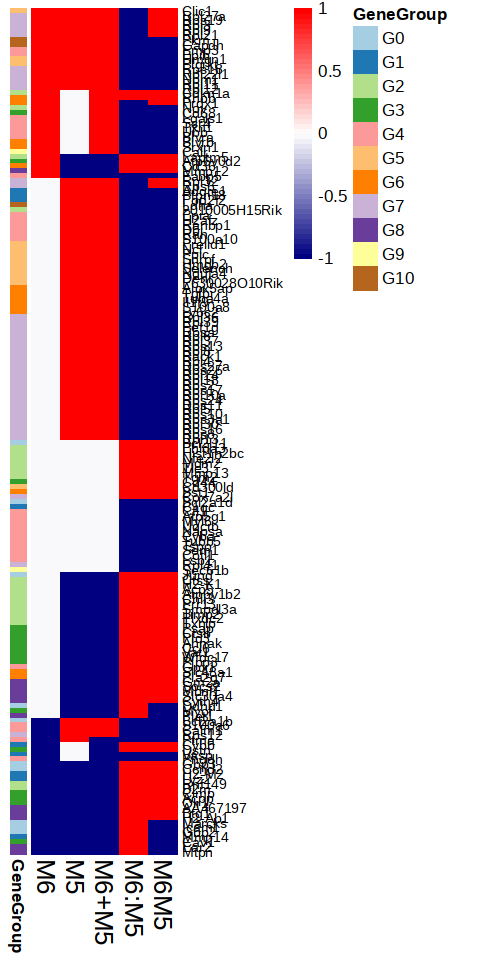

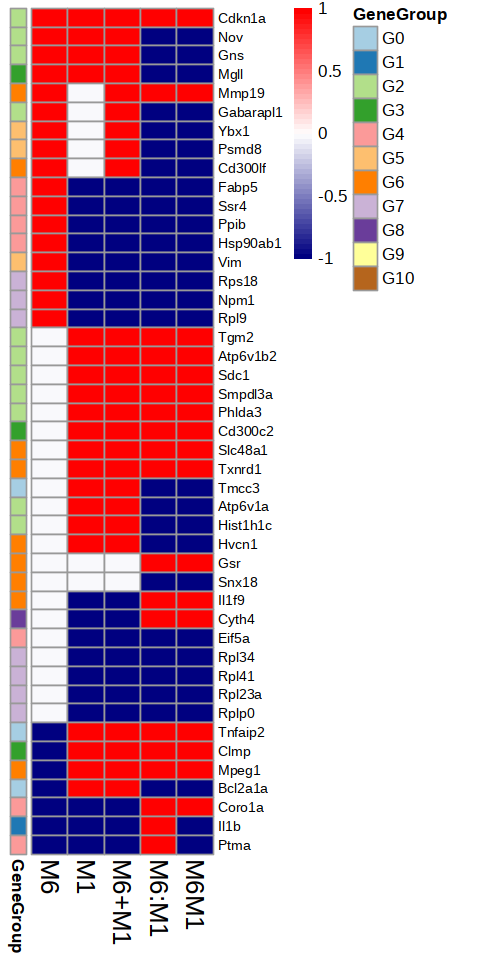

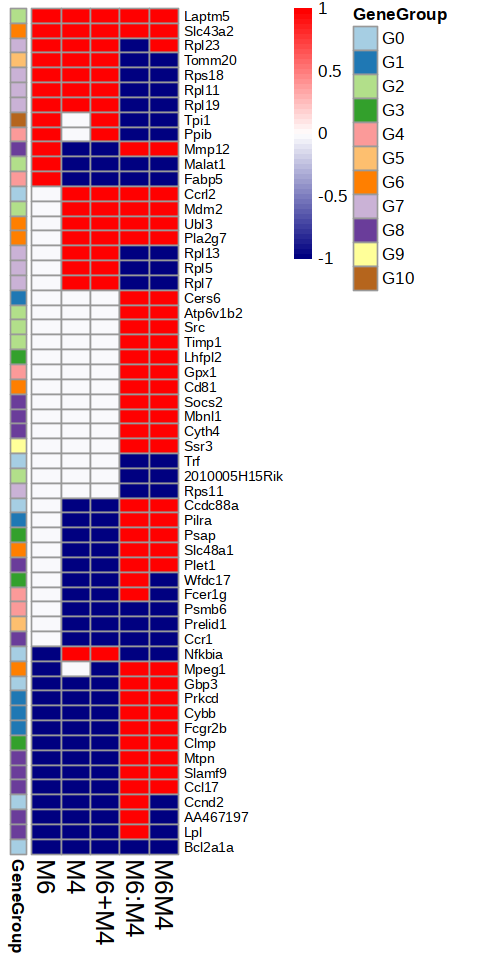

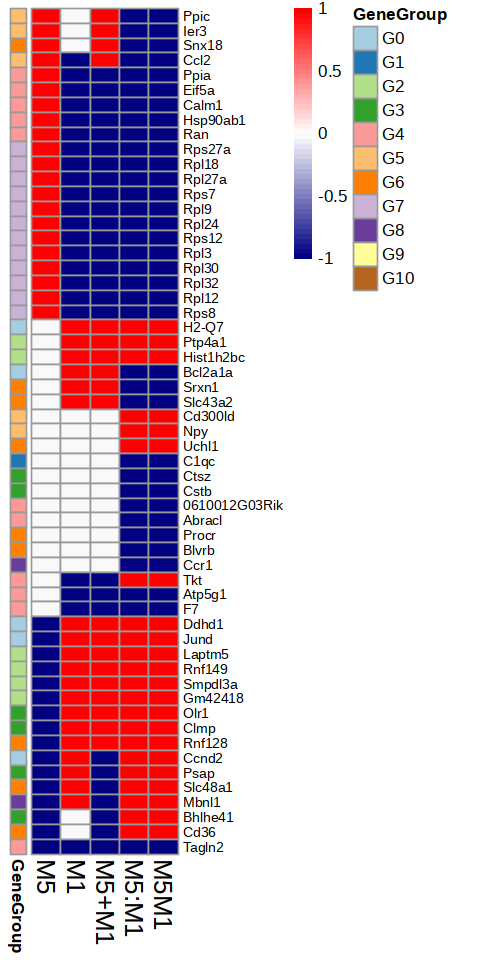

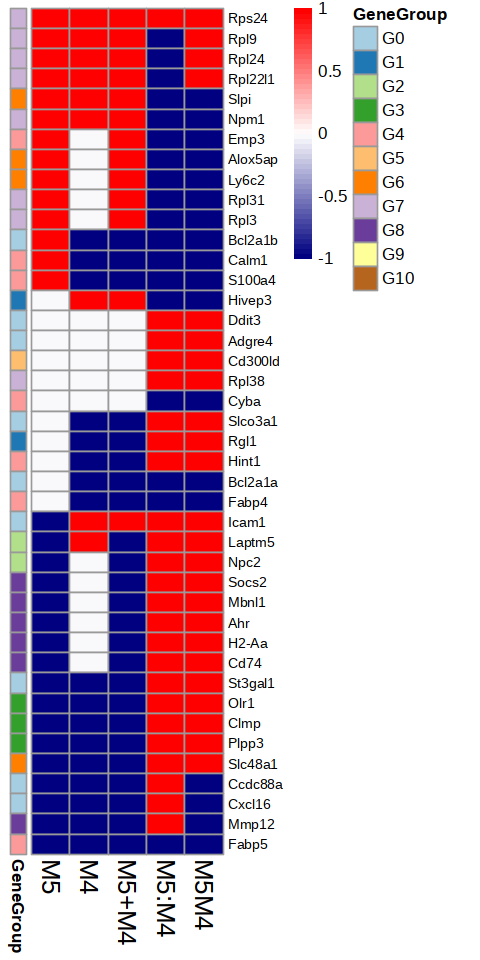

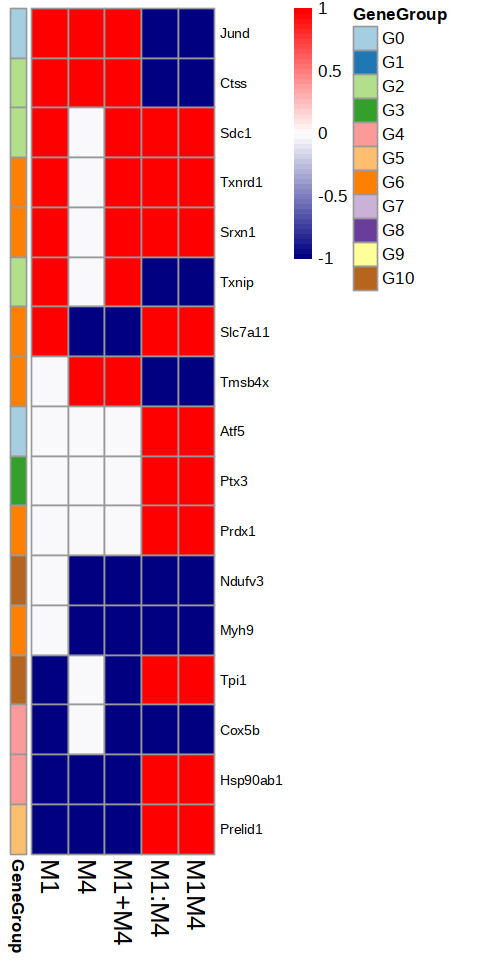

In [11]:
options(repr.plot.width = 4, repr.plot.height = 8)

for (elem in unique(combosInterMelt$variable)) {
    group <- combosInterMelt[combosInterMelt$variable == elem, ]
    g1 <- unique(group$Group1)
    g2 <- unique(group$Group2)

    tp <- group[, c("Group1Value", "Group2Value", "value")]
    tp$bothKnockouts <- rowSums(tp)
    tp$sumOfMain     <- tp$Group1Value + tp$Group2Value
    colnames(tp) <- c(g1, g2, elem, paste0(g1, g2), paste0(g1, "+", g2))
    tp <- tp[, c(g1, g2, paste0(g1, "+", g2), elem, paste0(g1, g2))]
    rownames(tp) <- group$Gene

    myAnnot <- myGeneModules[rownames(tp), , drop = FALSE]

    tp[tp > 0] <-  1
    tp[tp < 0] <- -1
    tp <- tp[order(-tp[, 1], -tp[, 2], -tp[, 3], -tp[, 4], -tp[, 5], myAnnot$GeneGroup), ]
    colnames(tp) <- moduleLabel(colnames(tp))

    tt <- pheatmap(tp,
                   cluster_cols = FALSE,
                   cluster_rows = FALSE,
                   clustering_method = "ward.D",
                   treeheight_col = 0, treeheight_row = 0,
                   fontsize_row = 8, fontsize_col = 15,
                   annotation_row = myAnnot,
                   annotation_colors = annoCols,
                   colorRampPalette(c("navy", "white", "red"))(50))

    save_pheatmap_pdf(tt, paste0("figures/", gsub(":", "_", moduleLabel(elem)), ".pdf"),
                      width = 4, height = 15)
}